In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# netCDF4 needs to be installed in your environment for this to work
import xarray as xr
import rioxarray as rxr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import copernicusmarine as cm

# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")

# Optional - set your working directory if you wish to use the data
# accessed lower down in this notebook (the USA state boundary data)
os.chdir(os.path.join(et.io.HOME,
                      'projets',
                      'geotorch',
                      'appli_sst',
                      'data',))


In [2]:
# Chemin vers votre fichier NetCDF téléchargé
file_path = '/home/tromary/projets/geotorch/data/20240718000000-DMI-L3S_GHRSST-SSTsubskin-night_SST_UHR_NRT-NSEABALTIC-v02.0-fv01.0.nc'

# Ouverture du fichier NetCDF
ds = xr.open_dataset(file_path)
ds

/tmp/ipykernel_772934/160276924.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)


<xarray.Dataset> Size: 87MB
Dimensions:                  (lon: 2001, lat: 901, time: 1)
Coordinates:
  * lon                      (lon) float32 8kB -10.0 -9.98 -9.96 ... 29.98 30.0
  * lat                      (lat) float32 4kB 48.0 48.02 48.04 ... 65.98 66.0
  * time                     (time) datetime64[ns] 8B 2024-07-18
Data variables:
    sea_surface_temperature  (time, lat, lon) float32 7MB ...
    sses_standard_deviation  (time, lat, lon) float32 7MB ...
    sses_bias                (time, lat, lon) float32 7MB ...
    mask                     (time, lat, lon) float32 7MB ...
    sea_ice_fraction         (time, lat, lon) float32 7MB ...
    quality_level            (time, lat, lon) float32 7MB ...
    source_of_sst            (time, lat, lon) float32 7MB ...
    sum_sst                  (time, lat, lon) float32 7MB ...
    sum_square_sst           (time, lat, lon) float32 7MB ...
    sst_dtime                (time, lat, lon) timedelta64[ns] 14MB ...
    or_number_of_sst_pixels  (time, lat, lon) float32 7MB ...
Attributes: (12/47)
    Conventions:                CF-1.6
    title:                      DMI North Sea/Baltic Sea SST, L3S, (SST_BAL_S...
    summary:                    DMI Sea Surface Temperature  supercollated le...
    references:                 Høyer, J. L., Le Borgne, P., & Eastwood, S. (...
    institution:                Danish Meteorological Institute, DMI
    history:                    Version 1.0
    ...                         ...
    publisher_name:             GHRSST project office
    publisher_url:              http://www.ghrsst.org
    publisher_email:             ghrsst-po@nceo.ac.uk
    processing_level:           L3S
    cdm_data_type:              grid
    comment:                    IN NO EVENT SHALL DMI OR ITS REPRESENTATIVES ...

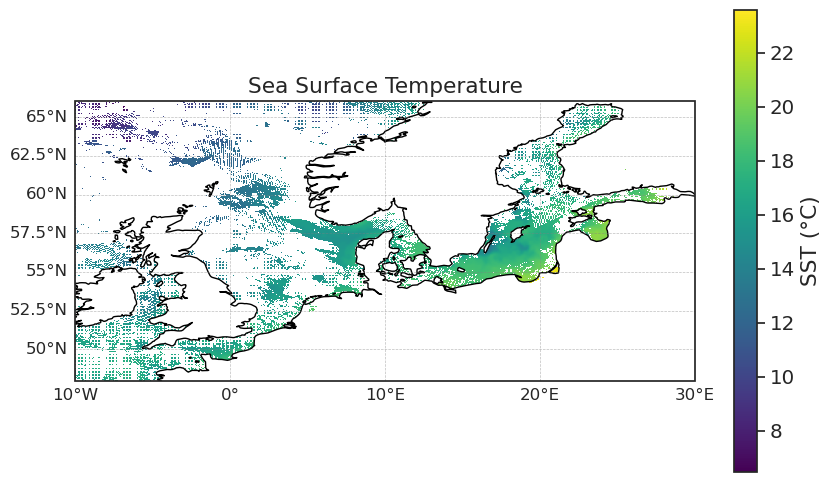

In [3]:
sst2d = ds['sea_surface_temperature'].squeeze()
sst2d_celsius = sst2d - 273.15

plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
sst2d_celsius.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={'label': 'SST (°C)'})
ax.coastlines()
ax.set_title("Sea Surface Temperature")
# Ajout des graduations et labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [4]:
print("Shape SST :", ds['sea_surface_temperature'].shape)

Shape SST : (1, 901, 2001)


In [5]:
print("Taille latitude :", ds['lat'].size)
print("Taille longitude :", ds['lon'].size)
print("Nombre total de points spatiaux :", ds['lat'].size * ds['lon'].size)

Taille latitude : 901
Taille longitude : 2001
Nombre total de points spatiaux : 1802901


In [6]:
print("Nombre de points océaniques (mask == 1) :", np.sum(ds['mask'].values == 1))

Nombre de points océaniques (mask == 1) : 764876


In [7]:
lat = ds['lat'].values
lon = ds['lon'].values
sst2d = ds['sea_surface_temperature'].squeeze().values - 273.15
sst2d = sst2d - np.mean(sst2d[np.isfinite(sst2d)])  # Centrage
mask2d = ds['mask'].squeeze().values if 'mask' in ds else np.ones_like(sst2d)

# Mise à plat des données
lat_flat, lon_flat = np.meshgrid(lat, lon, indexing='ij')
lat_flat = lat_flat.flatten()
lon_flat = lon_flat.flatten()
sst_flat = sst2d.flatten()
mask_flat = mask2d.flatten()

df = pd.DataFrame({
    'lat': lat_flat,
    'lon': lon_flat,
    'sst': sst_flat,
    'mask': mask_flat
})

# Points à prédire = pas d'observation SST ou masque ≠ 1
df_predict = df[(~np.isfinite(df['sst'])) & (df['mask'] == 1)].copy()

print(f"Nombre de points à prédire : {len(df_predict)}")
print(df_predict.head())

Nombre de points à prédire : 557315
    lat    lon  sst  mask
0  48.0 -10.00  NaN   1.0
1  48.0  -9.98  NaN   1.0
2  48.0  -9.96  NaN   1.0
3  48.0  -9.94  NaN   1.0
4  48.0  -9.92  NaN   1.0


In [8]:
lat = ds['lat']
lon = ds['lon']
sst = ds['sea_surface_temperature'] - 273.15 # Assurez-vous que le nom de la variable correspond à votre fichier
sst_mean = np.mean(sst.values[np.isfinite(sst.values)])
sst = sst - sst_mean  # Centrage
sst_std = ds['sses_standard_deviation']
mask = ds['mask'] if 'mask' in ds else None  # Certains fichiers n'ont pas de masque explicite

# Retirer la dimension 'time' (supposée de taille 1)
sst2d = sst.squeeze('time')
sst_std2d = sst_std.squeeze('time')

if mask is not None:
    mask2d = mask.squeeze('time')
else:
    mask2d = None

# Créer les grilles 2D de latitude et longitude
lon2d, lat2d = np.meshgrid(lon.values, lat.values)

# Mise à plat des données (flatten)
lat_flat = lat2d.flatten()
lon_flat = lon2d.flatten()
sst_flat = sst2d.values.flatten()
sst_std_flat = sst_std2d.values.flatten()
if mask2d is not None:
    mask_flat = mask2d.values.flatten()
else:
    mask_flat = np.ones_like(sst_flat)  # Si pas de masque, tout est valide

# Construction du DataFrame pandas
df = pd.DataFrame({
    'lat': lat_flat,
    'lon': lon_flat,
    'sst': sst_flat,
    'sst_std': sst_std_flat,
    'mask': mask_flat
})

print(df.describe())
print(np.isfinite(df['sst']).sum())
# Tronquer la base de données au-delà de 60°N et de 10°E
#df_tronque = df[(df['lat'] <= 60) & (df['lon'] <= 10)].copy()
print(sst_mean)
#print(df_tronque.describe())
#print(df_tronque.shape)
# Si vous souhaitez le résumé uniquement sur les points valides (masque == 1 et SST non NaN)


                lat           lon           sst        sst_std          mask
count  1.802901e+06  1.802901e+06  2.075610e+05  207561.000000  1.802901e+06
mean   5.700000e+01  1.000000e+01  6.681018e-07       0.522499  1.575753e+00
std    5.210337e+00  1.154865e+01  2.449658e+00       0.146394  4.983060e-01
min    4.800000e+01 -1.000000e+01 -9.425483e+00       0.280000  1.000000e+00
25%    5.250000e+01 -2.682209e-07 -1.285499e+00       0.400000  1.000000e+00
50%    5.700000e+01  9.999999e+00  3.245173e-01       0.460000  2.000000e+00
75%    6.150000e+01  2.000000e+01  1.564507e+00       0.700000  2.000000e+00
max    6.600000e+01  3.000000e+01  7.674493e+00       0.700000  2.000000e+00
207561
15.905494


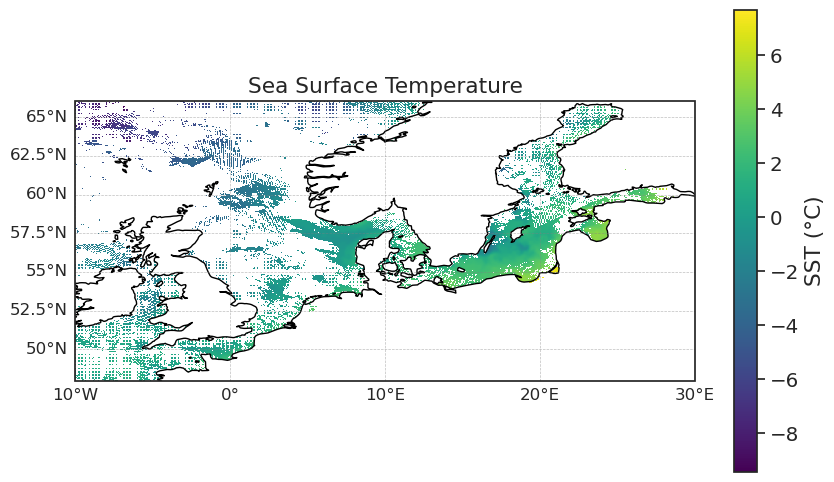

In [9]:
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

sst = df['sst'].values.reshape(len(df['lat'].unique()), len(df['lon'].unique()))
lat = np.sort(df['lat'].unique())
lon = np.sort(df['lon'].unique())

mesh = ax.pcolormesh(lon, lat, sst, cmap='viridis')
plt.colorbar(mesh, ax=ax, label='SST (°C)')
ax.coastlines()
ax.set_title("Sea Surface Temperature")
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

     lon   lat         x         y  sst
0 -10.00  48.0 -1.356932  5.626727  NaN
1  -9.98  48.0 -1.355463  5.626218  NaN
2  -9.96  48.0 -1.353993  5.625709  NaN
3  -9.94  48.0 -1.352523  5.625201  NaN
4  -9.92  48.0 -1.351053  5.624693  NaN
(1802901, 7)
                 lat            lon           sst        sst_std      mask  \
count  207561.000000  207561.000000  2.075610e+05  207561.000000  207561.0   
mean       57.174885       8.025777  6.681018e-07       0.522499       1.0   
std         4.254421      10.295481  2.449658e+00       0.146394       0.0   
min        48.000000     -10.000000 -9.425483e+00       0.280000       1.0   
25%        54.799999      -0.180000 -1.285499e+00       0.400000       1.0   
50%        56.959999       7.280000  3.245173e-01       0.460000       1.0   
75%        59.700001      18.260000  1.564507e+00       0.700000       1.0   
max        66.000000      28.820000  7.674493e+00       0.700000       1.0   

                   x              y  
count 

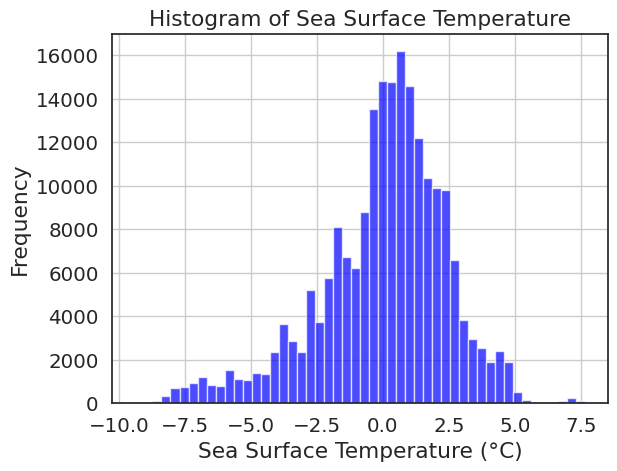

                 lat            lon  sst  sst_std      mask              x  \
count  557315.000000  557315.000000  0.0      0.0  557315.0  557315.000000   
mean       59.244450       1.297552  NaN      NaN       1.0      -0.283786   
std         4.630946       8.757415  NaN      NaN       0.0       0.519131   
min        48.000000     -10.000000  NaN      NaN       1.0      -1.356932   
25%        56.000000      -5.600000  NaN      NaN       1.0      -0.631383   
50%        59.799999      -0.040000  NaN      NaN       1.0      -0.348674   
75%        63.180000       4.860000  NaN      NaN       1.0      -0.058143   
max        66.000000      30.000000  NaN      NaN       1.0       1.483772   

                   y  
count  557315.000000  
mean        6.680759  
std         0.497627  
min         5.505206  
25%         6.316615  
50%         6.752094  
75%         7.105212  
max         7.545904  


In [10]:
from pyproj import CRS, Transformer

# Exemple : projection UTM zone 33N (EPSG:32633) - à adapter selon votre région
# ETRS89 / UTM zone 33N : EPSG:25833
crs_wgs84 = CRS.from_epsg(4326)      # Système géographique (lat/lon)
crs_etrs89 = CRS.from_epsg(25833)    # ETRS89 / UTM zone 33N

transformer = Transformer.from_crs(crs_wgs84, crs_etrs89, always_xy=True)

# Application sur vos colonnes longitude/latitude
x, y = transformer.transform(df['lon'].values, df['lat'].values)
df['x'] = x * 10**(-6)
df['y'] = y * 10**(-6)

print(df[['lon', 'lat', 'x', 'y','sst']].head())
print(df.shape)

df_valid = df[(df['mask'] == 1) & np.isfinite(df['sst'])]
print(df_valid.describe())

print(df_valid.shape)

plt.hist(df_valid['sst'], bins=50, color='blue', alpha=0.7)
plt.xlabel('Sea Surface Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Histogram of Sea Surface Temperature')
plt.grid()
plt.show()

df_predict = df[(~np.isfinite(df['sst'])) & (df['mask'] == 1)].copy()
print(df_predict.describe())

In [40]:
df_valid.to_csv("df_valid.csv", index=False)
df_predict.to_csv("df_predict.csv", index=False)

# Extraction et visualisation des prédictions


In [11]:
df_pred = pd.read_csv("../df_grid.csv")
# Vérifie la présence des colonnes nécessaires
print(df_pred.columns)
df_pred.describe()


Index(['lat', 'lon', 'sst', 'sst_std', 'mask', 'x', 'y', 'learned_pred',
       'learned_var', 'guessed_pred', 'guessed_var'],
      dtype='object')


,lat,lon,sst,sst_std,mask,x,y,learned_pred,learned_var,guessed_pred,guessed_var
count,557315.000000,557315.000000,0.0,0.0,557315.0,557315.000000,557315.000000,557315.000000,557315.000000,557315.000000,557315.000000
mean,59.244452,1.297552,NaN,NaN,1.0,-0.283786,6.680759,-1.933099,1.356143,-2.059271,1.934212
std,4.631601,8.758212,NaN,NaN,0.0,0.519131,0.497627,2.503283,0.204633,2.552970,0.502941
min,48.000000,-10.000000,NaN,NaN,1.0,-1.356932,5.505206,-9.774299,0.300857,-9.916120,0.299135
25%,56.000000,-5.600000,NaN,NaN,1.0,-0.631383,6.316615,-3.511641,1.312150,-3.661842,1.596007
50%,59.800000,-0.040000,NaN,NaN,1.0,-0.348674,6.752094,-1.709196,1.443923,-2.020527,2.078665
75%,63.180000,4.860000,NaN,NaN,1.0,-0.058143,7.105212,-0.107809,1.491527,-0.102758,2.380883
max,66.000000,30.000000,NaN,NaN,1.0,1.483772,7.545904,7.835641,1.508322,7.991862,2.474087


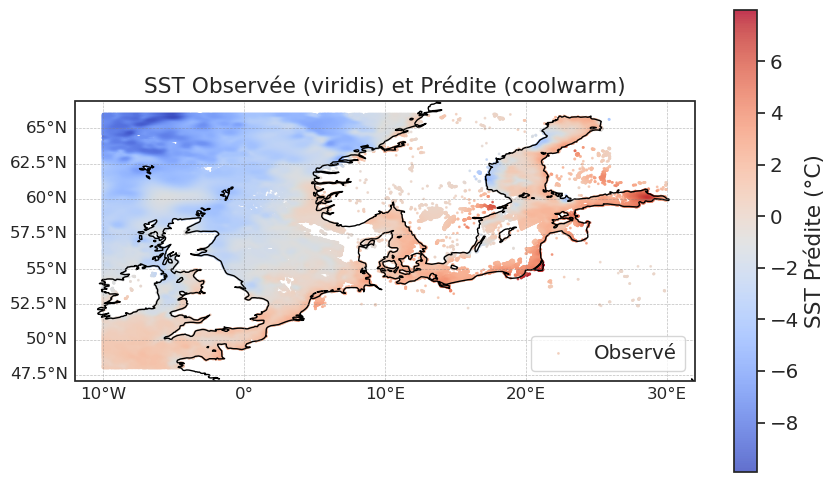

In [12]:
# Chargement des données observées et prédites
df_valid = pd.read_csv("df_valid.csv")
df_predict = pd.read_csv("../df_grid.csv")

plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Observé (points où tu as la vraie SST)
#sc1 = ax.scatter(df_valid['lon'], df_valid['lat'], c=df_valid['sst'], cmap='viridis', s=1, label='Observé', alpha=0.8)

# Prédit (points où tu n'as pas la vraie SST)
sc2 = ax.scatter(df_predict['lon'], df_predict['lat'], c=df_predict['guessed_pred'], cmap='coolwarm', s=1, label='Prédit', alpha=0.8)

#plt.colorbar(sc1, ax=ax, label='SST Observée (°C)')
plt.colorbar(sc2, ax=ax, label='SST Prédite (°C)')
ax.coastlines()
ax.set_title("SST Observée (viridis) et Prédite (coolwarm)")
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend(["Observé", "Prédit"])
plt.show()

In [13]:
import cartopy.feature as cfeature
from shapely.geometry import Point
from shapely.ops import unary_union
import geopandas as gpd

def mask_land_points(df, lon_col='lon', lat_col='lat'):
    # Récupère les côtes (land polygons)
    land = cfeature.NaturalEarthFeature('physical', 'land', '10m')
    geoms = [geom for geom in land.geometries()]
    land_union = unary_union(geoms)

    # Teste chaque point
    mask = []
    for lon, lat in zip(df[lon_col], df[lat_col]):
        pt = Point(lon, lat)
        mask.append(not land_union.contains(pt))  # True si en mer

    return np.array(mask)


In [77]:
# Chargement des données
df_valid = pd.read_csv("df_valid.csv")      # points observés (avec 'sst')
df_grid = pd.read_csv("../df_grid.csv")     # points prédits (avec 'guessed_pred')

# On suppose que df_valid et df_grid ont les colonnes 'lat', 'lon'
# Fusion des deux DataFrames sur lat/lon
df_valid = df_valid[['lat', 'lon', 'sst']]
df_grid = df_grid[['lat', 'lon', 'learned_pred','guessed_pred']]

# Renommer la colonne de prédiction pour uniformiser
#df_grid = df_grid.rename(columns={'learned_pred': 'sst_pred'})
df_grid[['learned_pred']] = df_grid[['learned_pred']] + sst_mean
df_grid[['guessed_pred']] = df_grid[['guessed_pred']] + sst_mean


# Création d'un DataFrame complet avec tous les points uniques
df_all = pd.concat([
    df_valid[['lat', 'lon']],
    df_grid[['lat', 'lon']]
]).drop_duplicates().reset_index(drop=True)

# Ajout des colonnes SST observée et prédite
df_all = df_all.merge(df_valid[['lat', 'lon', 'sst']], on=['lat', 'lon'], how='left')
df_all = df_all.merge(df_grid[['lat', 'lon', 'learned_pred','guessed_pred']], on=['lat', 'lon'], how='left')

# Création des colonnes finales : SST observée si dispo, sinon prédite, sinon NaN
df_all['sst_learned_final'] = df_all['sst'] + sst_mean
df_all.loc[df_all['sst_learned_final'].isna(), 'sst_learned_final'] = df_all.loc[df_all['sst_learned_final'].isna(), 'learned_pred']
df_all['sst_guessed_final'] = df_all['sst'] + sst_mean
df_all.loc[df_all['sst_guessed_final'].isna(), 'sst_guessed_final'] = df_all.loc[df_all['sst_guessed_final'].isna(), 'guessed_pred']

df_all['diff'] = df_all['sst_learned_final'] - df_all['sst_guessed_final']

mask = mask_land_points(df_all)
# Appliquer le masque pour ne garder que les points en mer
df_all.loc[~mask, 'sst_learned_final'] = np.nan
df_all.loc[~mask, 'sst_guessed_final'] = np.nan



    lat   lon       sst  learned_pred  guessed_pred  sst_learned_final  \
0  48.0 -9.56  0.794519           NaN           NaN          16.700012   
1  48.0 -9.52  0.804498           NaN           NaN          16.709991   
2  48.0 -9.50  0.814508           NaN           NaN          16.720001   
3  48.0 -9.48  0.814508           NaN           NaN          16.720001   
4  48.0 -9.32  0.804498           NaN           NaN          16.709991   

   sst_guessed_final  diff  
0          16.700012   0.0  
1          16.709991   0.0  
2          16.720001   0.0  
3          16.720001   0.0  
4          16.709991   0.0  
lat                       0
lon                       0
sst                  557315
learned_pred         207561
guessed_pred         207561
sst_learned_final      5631
sst_guessed_final      5631
diff                   5631
dtype: int64


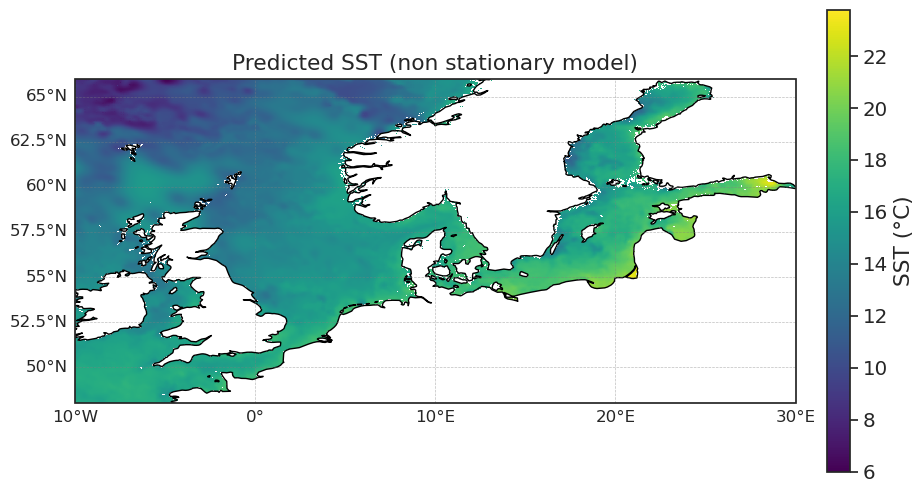

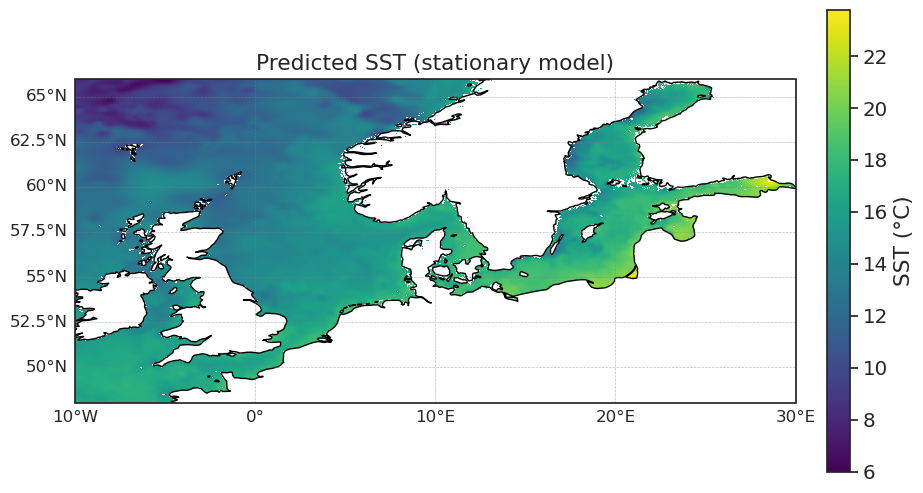

In [78]:
df_all.loc[~mask, 'diff'] = np.nan
print(df_all.head())
print(df_all.isna().sum())

# On suppose que df_all contient les colonnes 'lat', 'lon', 'sst_final'
sst_matrix_learned = df_all.pivot(index='lat', columns='lon', values='sst_learned_final').values
sst_matrix_guessed = df_all.pivot(index='lat', columns='lon', values='sst_guessed_final').values
#sst_matrix = df_all.pivot(index='lat', columns='lon', values='diff').values
lat_sorted = np.sort(df_all['lat'].unique())
lon_sorted = np.sort(df_all['lon'].unique())
sst_min = np.nanmin([sst_matrix_guessed, sst_matrix_learned])
sst_max = np.nanmax([sst_matrix_guessed, sst_matrix_learned])

plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lon_sorted, lat_sorted, sst_matrix_learned, cmap='viridis', vmin=sst_min, vmax=sst_max)
plt.colorbar(mesh, ax=ax, label='SST (°C)', fraction=0.03, pad=0.04)
ax.coastlines()
ax.set_title("Predicted SST (non stationary model)")
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lon_sorted, lat_sorted, sst_matrix_guessed, cmap='viridis', vmin=sst_min, vmax=sst_max)
plt.colorbar(mesh, ax=ax, label='SST (°C)', fraction=0.03, pad=0.04)
ax.coastlines()
ax.set_title("Predicted SST (stationary model)")
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [41]:

df_grid = pd.read_csv("../df_grid.csv")     # points prédits (avec 'guessed_pred')

# On suppose que df_valid et df_grid ont les colonnes 'lat', 'lon'
# Fusion des deux DataFrames sur lat/lon
df_grid = df_grid[['lat', 'lon', 'learned_pred', 'learned_var', 'guessed_pred', 'guessed_var']]
mask_pred = mask_land_points(df_grid)
df_grid.loc[~mask_pred, ['learned_var', 'guessed_var']] = np.nan


In [ ]:

# On suppose que df_all contient les colonnes 'lat', 'lon', 'sst_final'
sst_matrix_learned = df_grid.pivot(index='lat', columns='lon', values='learned_pred').values
sst_matrix_guessed = df_grid.pivot(index='lat', columns='lon', values='guessed_pred').values

sst_min = np.nanmin([sst_matrix_guessed, sst_matrix_learned])
sst_max = np.nanmax([sst_matrix_guessed, sst_matrix_learned])


lat_sorted = np.sort(df_grid['lat'].unique())
lon_sorted = np.sort(df_grid['lon'].unique())



In [69]:
df_valid = pd.read_csv("df_valid.csv")      # points observés (avec 'sst')
df_valid = df_valid[['lat', 'lon', 'sst']]

# Création d'un DataFrame complet avec tous les points uniques
df_all = pd.concat([
    df_valid[['lat', 'lon']],
    df_grid[['lat', 'lon']]
]).drop_duplicates().reset_index(drop=True)

df_all = df_all.merge(df_valid[['lat', 'lon', 'sst']], on=['lat', 'lon'], how='left')
df_all = df_all.merge(df_grid[['lat', 'lon', 'learned_var','guessed_var']], on=['lat', 'lon'], how='left')

# Création des colonnes finales : 0 si SST dispo (point d'entraînement), sinon variance de prédiction
df_all['learned_var'] = df_all['learned_var'].copy()
df_all.loc[df_all['sst'].notna(), 'learned_var'] = 0  # 0 aux points d'entraînement

df_all['guessed_var'] = df_all['guessed_var'].copy()
df_all.loc[df_all['sst'].notna(), 'guessed_var'] = 0  # 0 aux points d'entraînement

df_all.describe()

,lat,lon,sst,learned_var,guessed_var
count,764876.000000,764876.000000,2.075610e+05,759667.000000,759667.000000
mean,58.682843,3.123360,8.212543e-07,0.984721,1.402565
std,4.624880,9.674963,2.449749e+00,0.628575,0.960910
min,48.000000,-10.000000,-9.425483e+00,0.000000,0.000000
25%,55.480000,-4.860000,-1.285499e+00,0.000000,0.000000
50%,58.840000,1.380000,3.245172e-01,1.358418,1.736234
75%,62.640000,7.920000,1.564507e+00,1.476553,2.274729
max,66.000000,30.000000,7.674493e+00,1.508322,2.474065


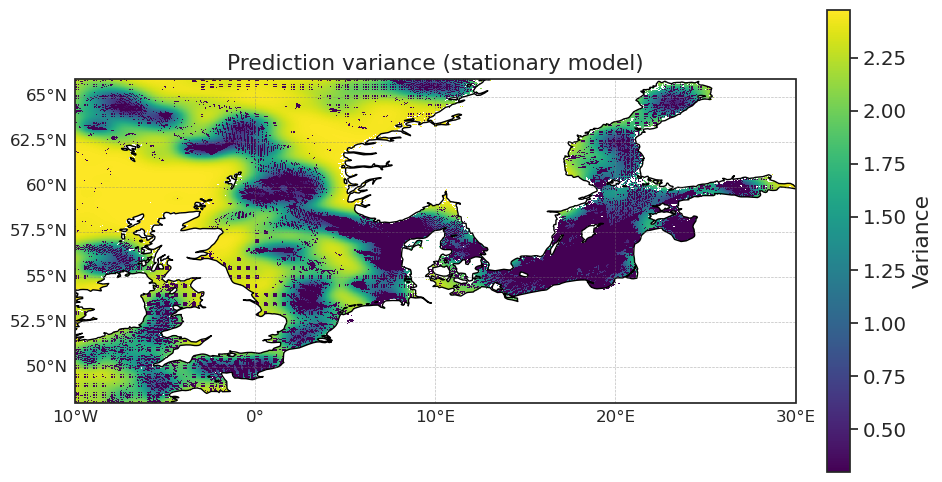

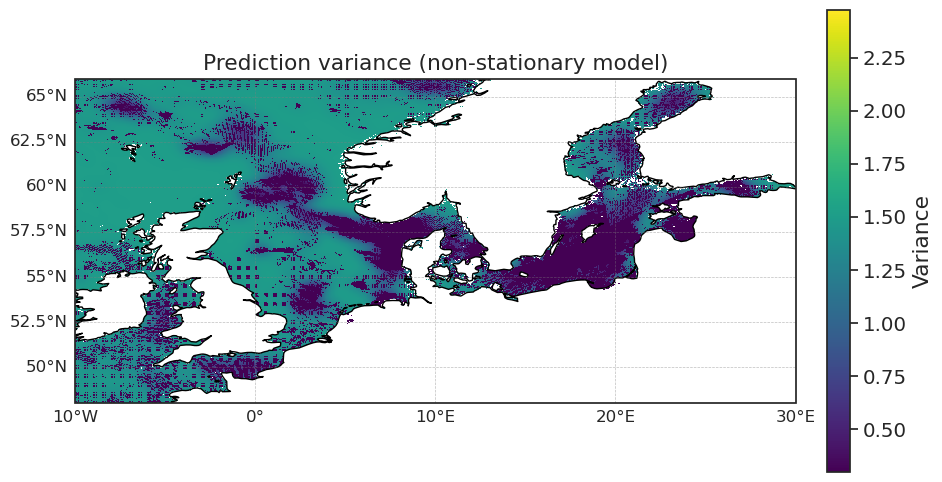

In [75]:

# Matrices de variance
var_matrix_guessed = df_all.pivot(index='lat', columns='lon', values='guessed_var').values
var_matrix_learned = df_all.pivot(index='lat', columns='lon', values='learned_var').values

lat_sorted = np.sort(df_all['lat'].unique())
lon_sorted = np.sort(df_all['lon'].unique())

# Calculer vmin et vmax en excluant les zéros pour mieux voir le contraste
var_guessed_nonzero = var_matrix_guessed[var_matrix_guessed > 0]
var_learned_nonzero = var_matrix_learned[var_matrix_learned > 0]
vmin = np.nanmin([var_guessed_nonzero, var_learned_nonzero])
vmax = np.nanmax([var_guessed_nonzero, var_learned_nonzero])

# Positions des données d'entraînement (df_valid contient les données d'entraînement)
train_lon = df_valid['lon'].values
train_lat = df_valid['lat'].values

# Carte 1 : Stationary model
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lon_sorted, lat_sorted, var_matrix_guessed, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(mesh, ax=ax, label='Variance', fraction=0.03, pad=0.04)
ax.coastlines()
ax.set_title("Prediction variance (stationary model)")
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

# Carte 2 : Non-stationary model
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lon_sorted, lat_sorted, var_matrix_learned, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(mesh, ax=ax, label='Variance', fraction=0.03, pad=0.04)
ax.coastlines()
ax.set_title("Prediction variance (non-stationary model)")
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [71]:
print(vmin, vmax)

0.0 2.4740648
